# Hot New Early Dark Energy

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import classy as classy

In [23]:
##Define cosmologies:

dict_general = {
    # General & Background
    'h': 0.67810,
    'T_cmb': 2.7255,
    'omega_b': 0.02238280,
    'omega_cdm': 0.1201075,
    'N_ur': 3.044,
    'Omega_k': 0.,
    'YHe': 'BBN',
    'recombination': 'recfast',
    
    # Reionization
    'reio_parametrization': 'reio_camb',
    'z_reio': 7.6711,
    'reionization_exponent': 1.5,
    'reionization_width': 0.5,
    'helium_fullreio_redshift': 3.5,
    'helium_fullreio_width': 0.5,
    
    # Perturbations & Output types
    'output': 'tCl,pCl,lCl,mPk',
    'modes': 's',
    'ic': 'ad',
    'gauge': 'synchronous',
    'lensing': 'yes',
    
    # Primordial Spectrum
    'k_pivot': 0.05,
    'A_s': 2.100549e-09,
    'n_s': 0.9660499,
    'alpha_s': 0.,
    
    # Spectra Limits & LSS
    'l_max_scalars': 2500,
    'P_k_max_h/Mpc': 1.,
    'z_pk': 0,
    
    # Verbosity
    'input_verbose': 0,
    'background_verbose': 0,
    'thermodynamics_verbose': 0,
    'perturbations_verbose': 0,
    'transfer_verbose': 0,
    'primordial_verbose': 0,
    'lensing_verbose': 0,
    'output_verbose': 0,
    'back_integration_stepsize': 1e-3,
    'perturb_integration_stepsize': 1e-3
}



# Make some helper functions for cleaner code in the notebook:

def run_cosmo(classy_version, dict_in):
    model = classy_version.Class()
    model.set(dict_in)
    model.compute()
    return model

def plot_Cl_TT(model, ax = None,**kwargs):

    # Get the computed data dictionary
    cl = model.lensed_cl(2500)
    l = cl['ell']
    # Compute C_l = l(l+1)C_l / 2pi (in muK^2)
    factor = l * (l + 1) / (2 * np.pi) * 1e12
    cl_TT = factor * cl['tt']

    if ax is not None:
        ax.plot(l, cl_TT, **kwargs)

    return l, cl_TT




## Running the Hot NEDE model in CLASS++:
We can start by running the LCDM model as a baseline:

In [24]:
model_LCDM = run_cosmo(classy, {**dict_general})

To activate Hot NEDE in CLASS++, we need to tell CLASS++ to compute it with four parameters:

G_over_aH_drmd_ini, 

delta_Neff_drmd, 

f_idm_drmd, 

z_stop.



In [25]:
dict_drmd={ 
        'G_over_aH_drmd_ini':1e5, # Interaction strength
        'delta_Neff_drmd':1.0, # Extra radiation from the DRMD component
        'f_idm_drmd':0.5, # Fraction of DM that is interacting
        'z_stop':500, # Redshift at which the interaction stops
}

model_Hot_NEDE = run_cosmo(classy, {**dict_general, **dict_drmd})



We can also extract some output values directly from classy:

In [26]:
print("Hot NEDE model outputs:")
print(f'Fraction of interacting dark radiation (compared to total energy density): f_idr_drmd = {model_Hot_NEDE.f_idr_drmd()}')
print(f'Redshift of decoupling: z_dec_drmd = {model_Hot_NEDE.z_dec_drmd()}')


Hot NEDE model outputs:
Fraction of interacting dark radiation (compared to total energy density): f_idr_drmd = 0.11838235723282768
Redshift of decoupling: z_dec_drmd = 51.83356067095277


In [27]:
N = 25

<>:73: SyntaxWarning: invalid escape sequence '\L'
<>:73: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_227853/2963136698.py:73: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')
/tmp/ipykernel_227853/2963136698.py:44: RuntimeWarning: invalid value encountered in divide
  (cls_drmd / cls_LCDM - 1) * 100,


Text(0.5, 1.0, 'Relative Difference to $\\Lambda$CDM')

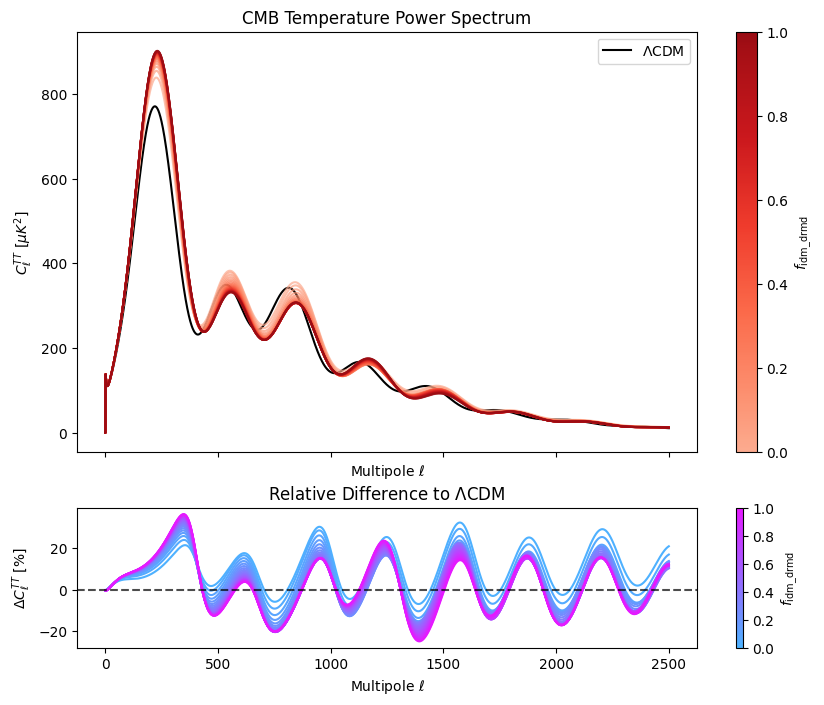

In [28]:
f_idm_drmds = np.linspace(0.01, 1.0, N)


fig, axs = plt.subplots(2,1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})



# --- Colormap setup ---
# Restrict range to avoid very light colors
def truncate_cmap(cmap, minval=0.3, maxval=0.9, n=100):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

cmap_drmd = truncate_cmap(cm.Reds)
cmap_ratio = truncate_cmap(cm.cool)

norm = mcolors.Normalize(vmin=0, vmax=1)


ls_LCDM, cls_LCDM = plot_Cl_TT(model_LCDM, ax=axs[0], label=r'$\Lambda$CDM', color='black')
for f_idm_drmd in f_idm_drmds:
    dict_drmd_local = {**dict_general, **dict_drmd, 'f_idm_drmd': f_idm_drmd}


    model_drmd_local = classy.Class()
    model_drmd_local.set(dict_drmd_local)
    model_drmd_local.compute()

    color_drmd = cmap_drmd(norm(f_idm_drmd))
    color_ratio = cmap_ratio(norm(f_idm_drmd))


    ls_drmd, cls_drmd = plot_Cl_TT(
        model_drmd_local, axs[0],
        color=color_drmd,
        alpha = 0.7
    )


    axs[1].plot(
        ls_drmd,
        (cls_drmd / cls_LCDM - 1) * 100,
        color=color_ratio
    )


axs[1].axhline(0, color='black', linestyle='--', alpha=0.7)

# --- Colorbars ---
sm_drmd = cm.ScalarMappable(cmap=cmap_drmd, norm=norm)
sm_drmd.set_array([])
cbar_drmd = fig.colorbar(sm_drmd, ax=axs[0])
cbar_drmd.set_label(r'$f_{\mathrm{idm\_drmd}}$')



sm_ratio = cm.ScalarMappable(cmap=cmap_ratio, norm=norm)
sm_ratio.set_array([])
cbar_ratio = fig.colorbar(sm_ratio, ax=axs[1])
cbar_ratio.set_label(r'$f_{\mathrm{idm\_drmd}}$')


# -------Axes labels and titles-------
axs[0].set_xlabel(r'Multipole $\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}$ [$\mu K^2$]')
axs[0].set_title('CMB Temperature Power Spectrum')
axs[0].legend()

axs[1].set_xlabel(r'Multipole $\ell$')
axs[1].set_ylabel(r'$\Delta C_\ell^{TT}$ [%]')
axs[1].set_title('Relative Difference to $\Lambda$CDM')

<>:72: SyntaxWarning: invalid escape sequence '\L'
<>:72: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_227853/790192118.py:72: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')
/tmp/ipykernel_227853/790192118.py:43: RuntimeWarning: invalid value encountered in divide
  (cls_drmd / cls_LCDM - 1) * 100,


Text(0.5, 1.0, 'Relative Difference to $\\Lambda$CDM')

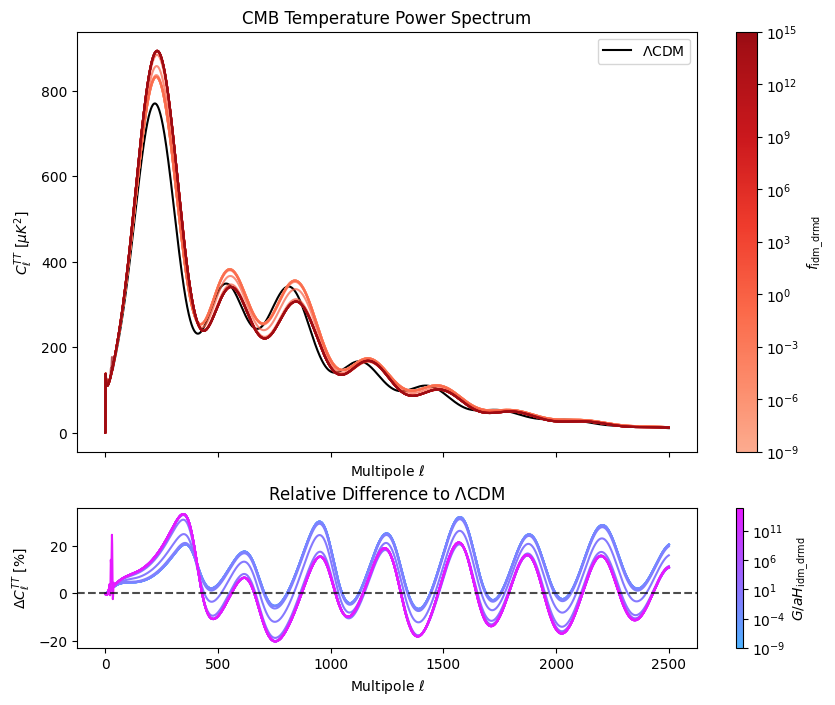

In [29]:
G_over_aH_drmd_inis = np.logspace(-9, 15, N)


fig, axs = plt.subplots(2,1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})



# --- Colormap setup ---
# Restrict range to avoid very light colors
def truncate_cmap(cmap, minval=0.3, maxval=0.9, n=100):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

cmap_drmd = truncate_cmap(cm.Reds)
cmap_ratio = truncate_cmap(cm.cool)

norm = mcolors.LogNorm(vmin=G_over_aH_drmd_inis.min(), vmax=G_over_aH_drmd_inis.max())

ls_LCDM, cls_LCDM = plot_Cl_TT(model_LCDM, ax=axs[0], label=r'$\Lambda$CDM', color='black')
for G_over_aH_drmd_ini in G_over_aH_drmd_inis:
    dict_drmd_local = {**dict_general, **dict_drmd, 'G_over_aH_drmd_ini': G_over_aH_drmd_ini}


    model_drmd_local = classy.Class()
    model_drmd_local.set(dict_drmd_local)
    model_drmd_local.compute()

    color_drmd = cmap_drmd(norm(G_over_aH_drmd_ini))
    color_ratio = cmap_ratio(norm(G_over_aH_drmd_ini))


    ls_drmd, cls_drmd = plot_Cl_TT(
        model_drmd_local, axs[0],
        color=color_drmd,
        alpha = 0.7
    )


    axs[1].plot(
        ls_drmd,
        (cls_drmd / cls_LCDM - 1) * 100,
        color=color_ratio
    )


axs[1].axhline(0, color='black', linestyle='--', alpha=0.7)

# --- Colorbars ---
sm_drmd = cm.ScalarMappable(cmap=cmap_drmd, norm=norm)
sm_drmd.set_array([])
cbar_drmd = fig.colorbar(sm_drmd, ax=axs[0])
cbar_drmd.set_label(r'$f_{\mathrm{idm\_drmd}}$')



sm_ratio = cm.ScalarMappable(cmap=cmap_ratio, norm=norm)
sm_ratio.set_array([])
cbar_ratio = fig.colorbar(sm_ratio, ax=axs[1])
cbar_ratio.set_label(r'$G/aH_{\mathrm{idm\_drmd}}$')


# -------Axes labels and titles-------
axs[0].set_xlabel(r'Multipole $\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}$ [$\mu K^2$]')
axs[0].set_title('CMB Temperature Power Spectrum')
axs[0].legend()

axs[1].set_xlabel(r'Multipole $\ell$')
axs[1].set_ylabel(r'$\Delta C_\ell^{TT}$ [%]')
axs[1].set_title('Relative Difference to $\Lambda$CDM')

<>:73: SyntaxWarning: invalid escape sequence '\L'
<>:73: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_227853/3368307376.py:73: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')
/tmp/ipykernel_227853/3368307376.py:44: RuntimeWarning: invalid value encountered in divide
  (cls_drmd / cls_LCDM - 1) * 100,


Text(0.5, 1.0, 'Relative Difference to $\\Lambda$CDM')

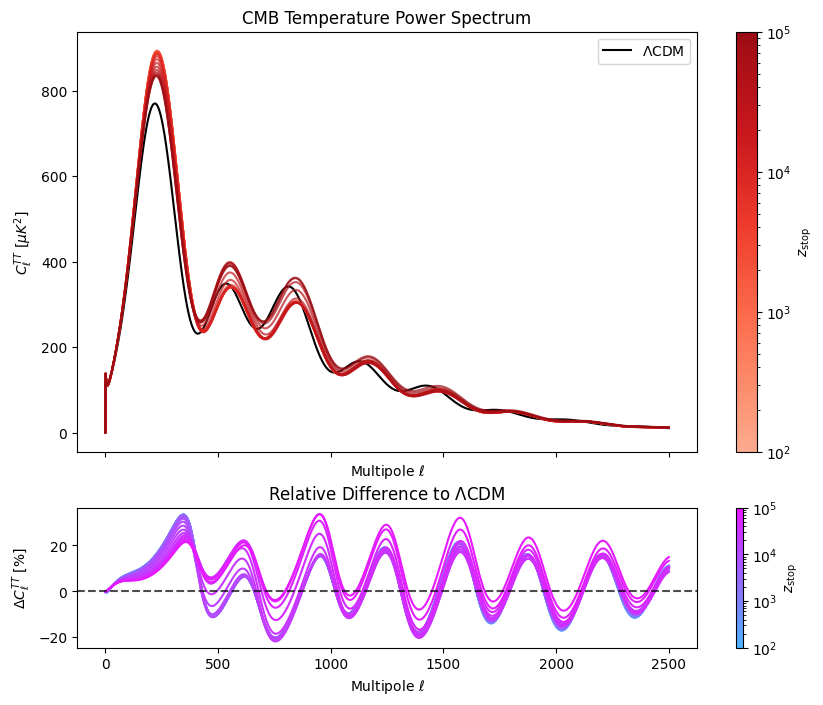

In [30]:
z_stops = np.logspace(2, 5, N)


fig, axs = plt.subplots(2,1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})



# --- Colormap setup ---
# Restrict range to avoid very light colors
def truncate_cmap(cmap, minval=0.3, maxval=0.9, n=100):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

cmap_drmd = truncate_cmap(cm.Reds)
cmap_ratio = truncate_cmap(cm.cool)

norm = mcolors.LogNorm(vmin=z_stops.min(), vmax=z_stops.max())


ls_LCDM, cls_LCDM = plot_Cl_TT(model_LCDM, ax=axs[0], label=r'$\Lambda$CDM', color='black')
for z_stop in z_stops:
    dict_drmd_local = {**dict_general, **dict_drmd, 'z_stop': z_stop}


    model_drmd_local = classy.Class()
    model_drmd_local.set(dict_drmd_local)
    model_drmd_local.compute()

    color_drmd = cmap_drmd(norm(z_stop))
    color_ratio = cmap_ratio(norm(z_stop))


    ls_drmd, cls_drmd = plot_Cl_TT(
        model_drmd_local, axs[0],
        color=color_drmd,
        alpha = 0.7
    )


    axs[1].plot(
        ls_drmd,
        (cls_drmd / cls_LCDM - 1) * 100,
        color=color_ratio
    )


axs[1].axhline(0, color='black', linestyle='--', alpha=0.7)

# --- Colorbars ---
sm_drmd = cm.ScalarMappable(cmap=cmap_drmd, norm=norm)
sm_drmd.set_array([])
cbar_drmd = fig.colorbar(sm_drmd, ax=axs[0])
cbar_drmd.set_label(r'$z_{\mathrm{stop}}$')



sm_ratio = cm.ScalarMappable(cmap=cmap_ratio, norm=norm)
sm_ratio.set_array([])
cbar_ratio = fig.colorbar(sm_ratio, ax=axs[1])
cbar_ratio.set_label(r'$z_{\mathrm{stop}}$')


# -------Axes labels and titles-------
axs[0].set_xlabel(r'Multipole $\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}$ [$\mu K^2$]')
axs[0].set_title('CMB Temperature Power Spectrum')
axs[0].legend()

axs[1].set_xlabel(r'Multipole $\ell$')
axs[1].set_ylabel(r'$\Delta C_\ell^{TT}$ [%]')
axs[1].set_title('Relative Difference to $\Lambda$CDM')

<>:72: SyntaxWarning: invalid escape sequence '\L'
<>:72: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_227853/586358244.py:72: SyntaxWarning: invalid escape sequence '\L'
  axs[1].set_title('Relative Difference to $\Lambda$CDM')
/tmp/ipykernel_227853/586358244.py:44: RuntimeWarning: invalid value encountered in divide
  (cls_drmd / cls_LCDM - 1) * 100,


Text(0.5, 1.0, 'Relative Difference to $\\Lambda$CDM')

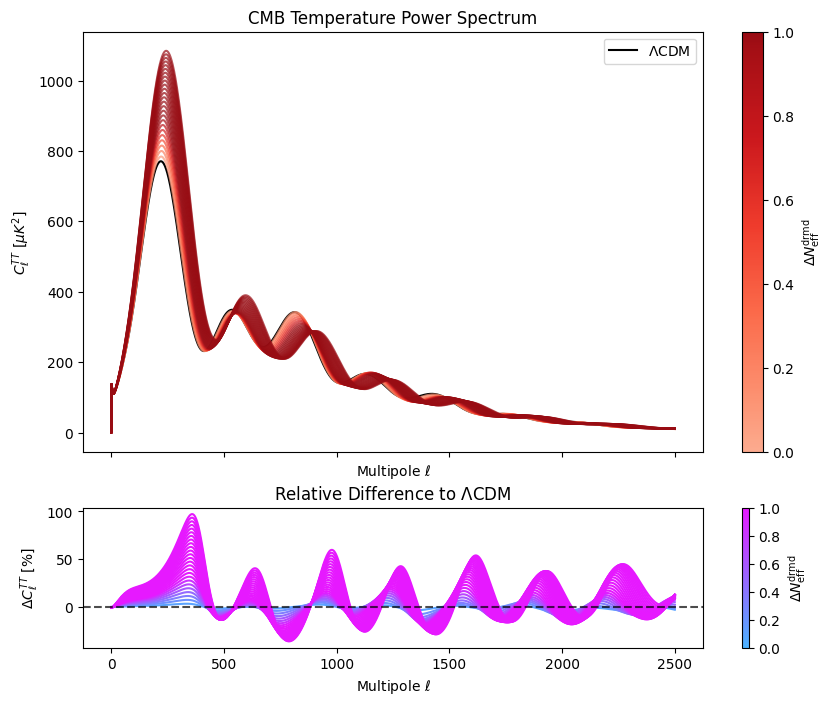

In [31]:
delta_Neff_drmds = np.linspace(0.1,3, N)


fig, axs = plt.subplots(2,1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})



# --- Colormap setup ---
# Restrict range to avoid very light colors
def truncate_cmap(cmap, minval=0.3, maxval=0.9, n=100):
    return mcolors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )

cmap_drmd = truncate_cmap(cm.Reds)
cmap_ratio = truncate_cmap(cm.cool)

norm = mcolors.Normalize(vmin=0, vmax=1)

ls_LCDM, cls_LCDM = plot_Cl_TT(model_LCDM, ax=axs[0], label=r'$\Lambda$CDM', color='black')
for delta_Neff_drmd in delta_Neff_drmds:
    dict_drmd_local = {**dict_general, **dict_drmd, 'delta_Neff_drmd': delta_Neff_drmd}


    model_drmd_local = classy.Class()
    model_drmd_local.set(dict_drmd_local)
    model_drmd_local.compute()

    color_drmd = cmap_drmd(norm(delta_Neff_drmd))
    color_ratio = cmap_ratio(norm(delta_Neff_drmd))


    ls_drmd, cls_drmd = plot_Cl_TT(
        model_drmd_local, axs[0],
        color=color_drmd,
        alpha = 0.7,
        label = ''
    )


    axs[1].plot(
        ls_drmd,
        (cls_drmd / cls_LCDM - 1) * 100,
        color=color_ratio
    )

axs[1].axhline(0, color='black', linestyle='--', alpha=0.7)

# --- Colorbars ---
sm_drmd = cm.ScalarMappable(cmap=cmap_drmd, norm=norm)
sm_drmd.set_array([])
cbar_drmd = fig.colorbar(sm_drmd, ax=axs[0])
cbar_drmd.set_label(r'$\Delta N_{\mathrm{eff}}^{\mathrm{drmd}}$')



sm_ratio = cm.ScalarMappable(cmap=cmap_ratio, norm=norm)
sm_ratio.set_array([])
cbar_ratio = fig.colorbar(sm_ratio, ax=axs[1])
cbar_ratio.set_label(r'$\Delta N_{\mathrm{eff}}^{\mathrm{drmd}}$')


# -------Axes labels and titles-------
axs[0].set_xlabel(r'Multipole $\ell$')
axs[0].set_ylabel(r'$C_\ell^{TT}$ [$\mu K^2$]')
axs[0].set_title('CMB Temperature Power Spectrum')
axs[0].legend()

axs[1].set_xlabel(r'Multipole $\ell$')
axs[1].set_ylabel(r'$\Delta C_\ell^{TT}$ [%]')
axs[1].set_title('Relative Difference to $\Lambda$CDM')